# Quiz 2 - Programming Excercises

## 1. Generalisation Error Bound

The code below creates a 2D binary classification dataset composed of two interleaving, moon-shaped half circles. (These data points are not really linearly separable.)

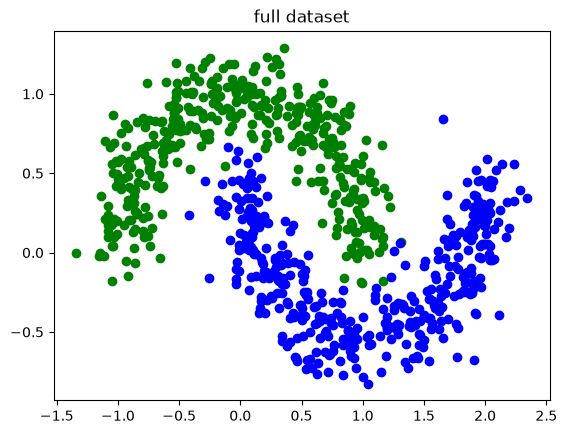

In [1]:
import numpy as np
import matplotlib.pyplot as plt


"""
# A two-moon dataset was generated with the following code

from sklearn.datasets import make_moons

# number of total samples
n_tot = 800
# number of training samples
n_tr = int(n_tot/2)

X, y = make_moons(n_tot, noise=0.15, random_state=0)

# divide data into training and testing
np.random.seed(42)
order = np.random.permutation(n_tot)
train = order[:n_tr]
test = order[n_tr:]

Xtr = X[train, :]
ytr = y[train]
Xtst = X[test, :]
ytst = y[test]


np.save("data/Xtr.npy", Xtr)
np.save("data/Xtst.npy", Xtst)
np.save("data/ytr.npy", ytr)
np.save("data/ytst.npy", ytst)
"""

# load the data
Xtr = np.load("data/Xtr.npy")
Xtst = np.load("data/Xtst.npy")
ytr = np.load("data/ytr.npy")
ytst = np.load("data/ytst.npy")
n = len(ytr)

plt.figure()
colors = ["g", "b"]
for (X, y) in [(Xtr, ytr), (Xtst, ytst)]:
    for ii in range(2):
        class_indices = np.where(y==ii)[0]
        plt.scatter(X[class_indices, 0], X[class_indices, 1], c=colors[ii])
plt.title("full dataset")
plt.show()


**Task 1a**: Consider a binary classifier called perceptron, calculate the generalisation error bounds for the sample sizes given in the template. To train with $m$ samples, use the first $m$ samples of the training set.

*Hint*: The Perceptron algorithm will be covered later in the course. For now, it's sufficient to know that it is a binary classifier. You could use it as follows:

```python
bc = binary_classifier()
# train the classifier on training data
bc.fit(Xtr, ytr)
# obtain predictions on test data
preds = bc.predict(Xtst)
```


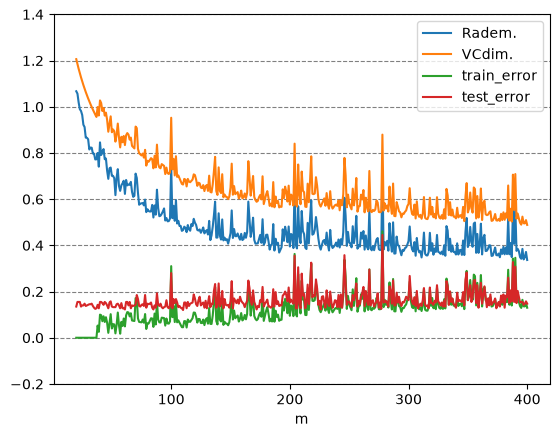

In [15]:
from sklearn.linear_model import Perceptron as binary_classifier

# Each curve is a pointwise bound at confidence 1 - delta.
delta = 0.05
vc_dimension = Xtr.shape[1] + 1  # affine linear classifiers in 2D: d = 3
ms = np.arange(20, n + 1)

train_errors = []
test_errors = []
rademachers = []
vcdims = []
differences_radem_test_error = []
differences_vc_test_error = []

for m in ms:
    bc = binary_classifier()
    bc.fit(Xtr[:m], ytr[:m])

    train_error = np.mean(bc.predict(Xtr[:m]) != ytr[:m])
    test_error = np.mean(bc.predict(Xtst) != ytst)
    train_errors.append(train_error)
    test_errors.append(test_error)

    random_errors = []

    # Measure Rademacher complexity
    for _ in range(100):
        sigma = np.random.choice([-1,1], size=m)
        random_model = binary_classifier()
        random_model.fit(Xtr[:m], sigma)
        random_model_pred = random_model.predict(Xtr[:m])
        random_training_error = np.mean(random_model_pred != sigma)
        random_errors.append(random_training_error)

    # Caculate the average of all random training errors
    avg_random_error = np.mean(random_errors)

    # Measure the rademacher R^S​(H) = 0.5 - e (average error when trying to fit random labels)
    rademacher = 0.5 - avg_random_error

    uncertainty = 3 * np.sqrt(np.log(2 / delta) / (2 * m))

    # Calculate generalization bound
    radem_bound = train_error + 2 * rademacher + uncertainty
    rademachers.append(radem_bound)

    # Measure VC dimension bound
    vc_uncertainty = (
        np.sqrt(
            2 * np.log(np.e * m / vc_dimension) / (m / vc_dimension)
        ) # VC complexity
        +
        np.sqrt(np.log(1 / delta) / (2 * m)) # confidence-term
    )

    vc_bound = train_error + vc_uncertainty
    vcdims.append(vc_bound)

    # Difference of the generalization bound and test error
    difference = radem_bound - test_error
    differences_radem_test_error.append(difference)

    difference_vc = vc_bound - test_error
    differences_vc_test_error.append(difference_vc)



# plot
plt.figure()
plt.plot(ms, rademachers, label="Radem.")
plt.plot(ms, vcdims, label="VCdim.")
plt.plot(ms, train_errors, label="train_error")
plt.plot(ms, test_errors, label="test_error")
plt.grid(axis='y', color='grey', linestyle='dashed')
plt.ylim(-0.2, 1.4)
plt.xticks(np.linspace(100, 400, 4))
plt.xlabel('m')
plt.legend()
plt.show()


**Task 1b**: Plot the difference of the generalisation bound based on Rademacher complexity, and the test error. Answer question 4.

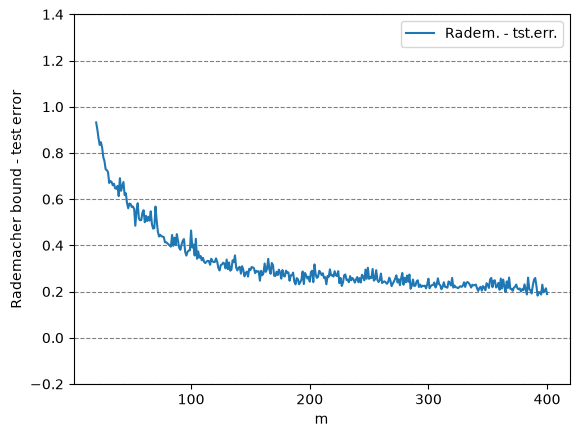

In [16]:
# TODO: calculate the difference of the generalisation bound based on Rademacher complexity, and the test error.


# TODO: plot the difference
plt.figure()
plt.plot(ms, differences_radem_test_error, label="Radem. - tst.err.")
plt.grid(axis='y', color='grey', linestyle='dashed')
plt.ylim(-0.2, 1.4)
plt.xticks(np.linspace(100, 400, 4))
plt.xlabel('m')
plt.ylabel("Rademacher bound - test error")
plt.legend()
plt.show()



**Task 1c**: Plot the difference of the generalisation bound based on VC-dimension, and the test error. Answer question 5.

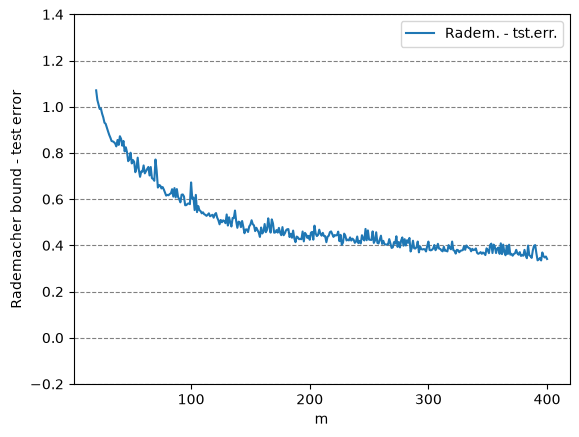

In [17]:
# TODO: calculate the difference of the generalisation bound based on VC-dimension, and the test error.
# vc_diffs = ...

# TODO: plot the difference
plt.figure()
plt.plot(ms,differences_vc_test_error , label="Radem. - tst.err.")
plt.grid(axis='y', color='grey', linestyle='dashed')
plt.ylim(-0.2, 1.4)
plt.xticks(np.linspace(100, 400, 4))
plt.xlabel('m')
plt.ylabel("Rademacher bound - test error")
plt.legend()
plt.show()
